<a href="https://colab.research.google.com/github/Faezeh94/sales-trend-analysis/blob/main/Sales_trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('sales_trends.csv')

# Fix date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Add calculated columns
df['Total Sales'] = df['Quantity Ordered'] * df['Price Each']
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Month Name'] = df['Order Date'].dt.strftime('%b')

print(df.shape)
df.head()

(120, 12)


,Order ID,Product,Category,Quantity Ordered,Price Each,Order Date,City,Region,Total Sales,Month,Quarter,Month Name
0,1001,iPhone,Electronics,2,700.00,2023-01-05,San Francisco,West,1400.00,1,1,Jan
1,1002,USB-C Charging Cable,Accessories,3,11.95,2023-01-07,Austin,South,35.85,1,1,Jan
2,1003,Macbook Pro Laptop,Electronics,1,1700.00,2023-01-10,New York City,East,1700.00,1,1,Jan
3,1004,AA Batteries (4-pack),Accessories,4,3.84,2023-01-12,Seattle,West,15.36,1,1,Jan
4,1005,Google Phone,Electronics,1,600.00,2023-01-15,Boston,East,600.00,1,1,Jan


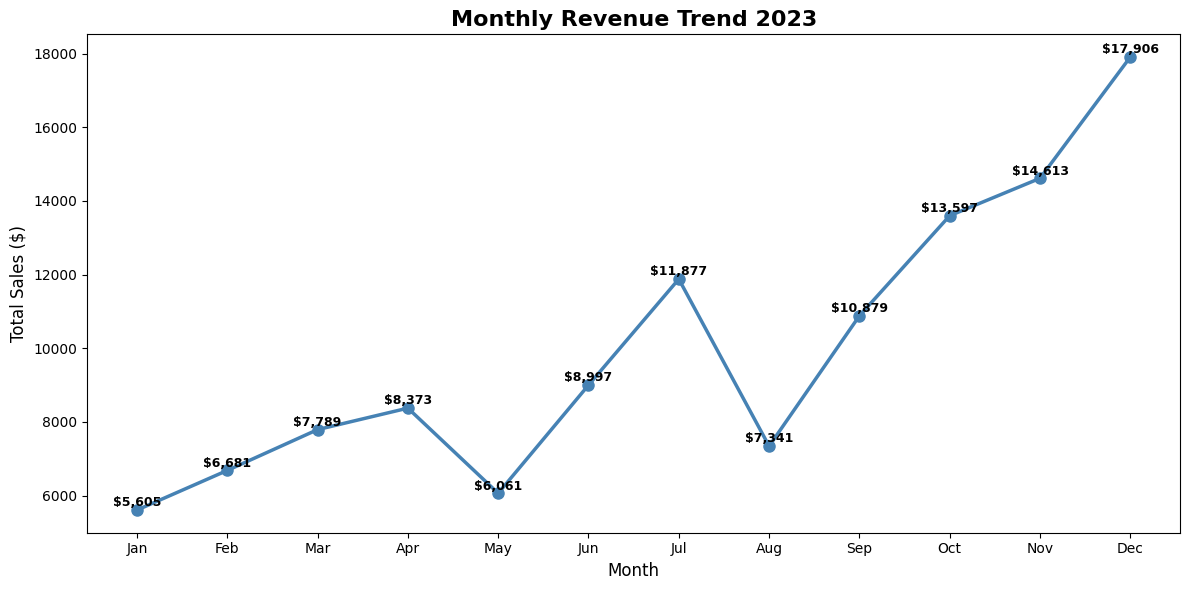

In [3]:
# Group by month and sum total sales
monthly_sales = df.groupby('Month')['Total Sales'].sum()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values,
         marker='o', color='steelblue', linewidth=2.5, markersize=8)

# Add value labels on each point
for x, y in zip(monthly_sales.index, monthly_sales.values):
    plt.text(x, y + 100, f'${y:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.title('Monthly Revenue Trend 2023', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

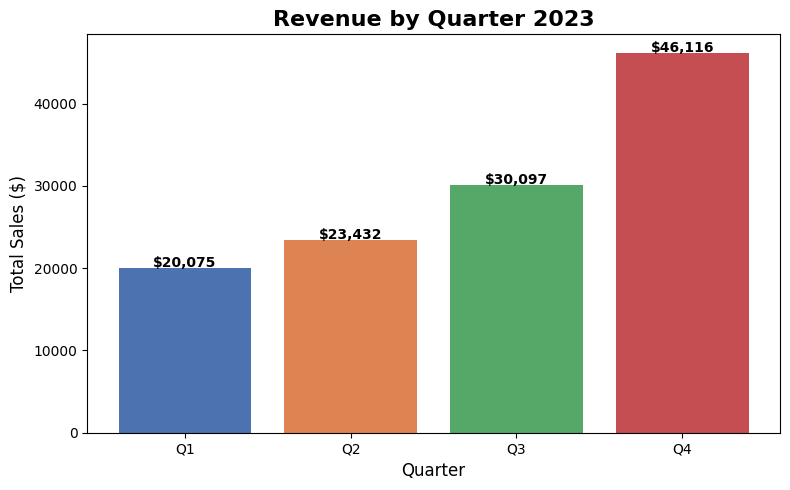

In [4]:
quarterly_sales = df.groupby('Quarter')['Total Sales'].sum()

plt.figure(figsize=(8, 5))
bars = plt.bar(['Q1','Q2','Q3','Q4'], quarterly_sales.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'])

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'${bar.get_height():,.0f}',
             ha='center', fontsize=10, fontweight='bold')

plt.title('Revenue by Quarter 2023', fontsize=16, fontweight='bold')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_20069/4180545962.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='Set2')


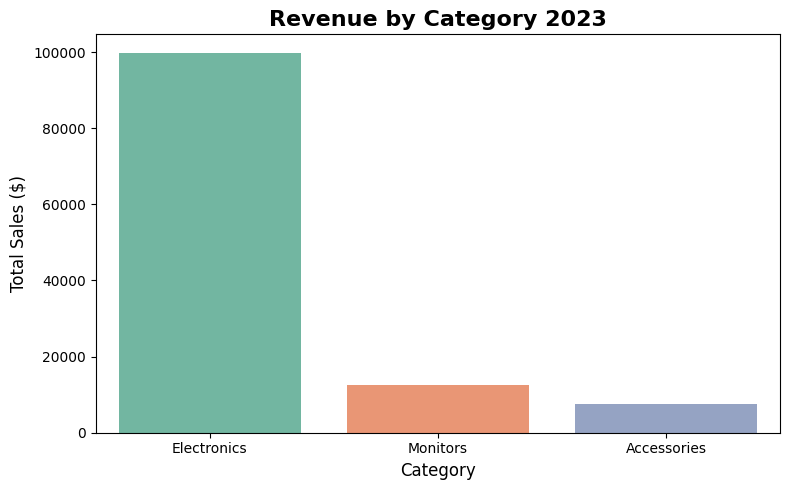

In [5]:
category_sales = df.groupby('Category')['Total Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Set2')

plt.title('Revenue by Category 2023', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.show()

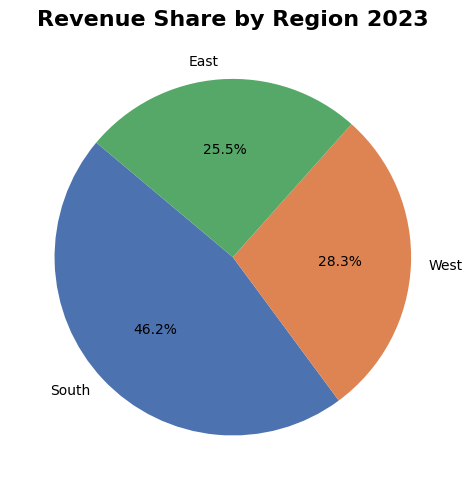

In [6]:
region_sales = df.groupby('Region')['Total Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.pie(region_sales.values, labels=region_sales.index,
        autopct='%1.1f%%', colors=['#4C72B0','#DD8452','#55A868'],
        startangle=140)

plt.title('Revenue Share by Region 2023', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()